# Hugging Face

In [1]:
# from dotenv import dotenv_values
# config = dotenv_values(".env/hf.env")
# config

# for k,v in config.items():
#   %env {k} {v}

%load_ext dotenv
%dotenv .env/hf.env

In [2]:
from transformers import pipeline

import pandas as pd
import torch
import random

# models

# NLP
_model_distilbert = "distilbert-base-uncased-finetuned-sst-2-english"
# text-classification
_model_huaen_question_detection = "huaen/question_detection"
_model_papluca_xlm_roberta = "papluca/xlm-roberta-base-language-detection"
_model_delphia_twitter_spam = "Delphia/twitter-spam-classifier"
# text-generation
_model_openai_gpt2 = "openai-community/gpt2"
# summarization
_model_facebook_bart_large_cnn = "facebook/bart-large-cnn"
# translation, translation_en_to_fr, translation_en_to_de, translation_en_to_zh, translation_zh_to_en
_model_google_t5 = "google-t5/t5-base"
_model_facebook_m2m100 = "facebook/m2m100_418M" # sentencepiece
# zero-shot-classification
_model_joeddav_xlm_roberta = "joeddav/xlm-roberta-large-xnli"
# question-answering
_model_deepset_roberta = "deepset/roberta-base-squad2"

# CV

_model_detr_resnet = "facebook/detr-resnet-50"
# zero-shot-image-classification
_model_openai_clip_vit = "openai/clip-vit-large-patch14-336"

In [ ]:
print(torch.cuda.is_available())

if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else:
  device = "cpu"
print(device)

# Transformers

## Examples

### Using a model directly

In [21]:
# Hugging Face in Action

from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(_model_distilbert)

model = AutoModelForSequenceClassification.from_pretrained(_model_distilbert)

text = "I loved the movie, it was fantastic!"
inputs = tokenizer(text, return_tensors = "pt")
outputs = model(**inputs)
predicted_label = torch.argmax(outputs.logits)
sentiment = "positive" if predicted_label == 1 else "negative"
sentiment

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

'positive'

### Using a transformers pipeline

In [12]:
# a pretrained DistilBERT model that has been fine-tuned on the Stanford Sentiment Treebank (SST-2) dataset for sentiment analysis in English
classifier = pipeline('text-classification', model=_model_distilbert)

text = '''
I thought this was a wonderful way to spend time on a too hot summer
weekend, sitting in the air conditioned theater and watching a
light-hearted comedy. The plot is simplistic, but the dialogue is
witty and the characters are likable (even the well bread suspected
serial killer). While some may be disappointed when they realize
this is not Match Point 2: Risk Addiction, I thought it was proof
that Woody Allen is still fully in control of the style many of us
have grown to love.<br /><br />This was the most I'd laughed at one
of Woody's comedies in years (dare I say a decade?). While I've never
been impressed with Scarlet Johanson, in this she managed to tone
down her "sexy" image and jumped right into a average, but spirited
young woman.<br /><br />This may not be the crown jewel of his career
, but it was wittier than "Devil Wears Prada" and more interesting
than "Superman" a great comedy to go see with friends.
'''
result = classifier(text)
pd.DataFrame(result)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,label,score
0,POSITIVE,0.99919


In [ ]:
classifier = pipeline("text-classification", model=_model_huaen_question_detection, device=device)

text = '''
I thought this was a wonderful way to spend time on a too hot summer
weekend, sitting in the air conditioned theater and watching a
light-hearted comedy. The plot is simplistic, but the dialogue is
witty and the characters are likable (even the well bread suspected
serial killer). While some may be disappointed when they realize
this is not Match Point 2: Risk Addiction, I thought it was proof
that Woody Allen is still fully in control of the style many of us
have grown to love.<br /><br />This was the most I'd laughed at one
of Woody's comedies in years (dare I say a decade?). While I've never
been impressed with Scarlet Johanson, in this she managed to tone
down her "sexy" image and jumped right into a average, but spirited
young woman.<br /><br />This may not be the crown jewel of his career
, but it was wittier than "Devil Wears Prada" and more interesting
than "Superman" a great comedy to go see with friends.
'''
result = classifier(text)
print(result)

classifier = pipeline("text-classification", model=_model_distilbert, device=device)
review1 = '''From the warm welcome to the exquisite dishes and impeccable
service, dining at Gourmet Haven is an unforgettable experience that
leaves you eager to return.'''
result = classifier(review1)
print(result)

review2 = '''Despite high expectations, our experience at Savor Bistro
fell short; the food was bland, service was slow, and the overall
atmosphere lacked charm, leaving us disappointed and unlikely to
revisit.'''
result = classifier(review2)
print(result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'non_question', 'score': 0.999713122844696}]


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9998437166213989}]
[{'label': 'NEGATIVE', 'score': 0.9997773766517639}]


In [9]:
try:
  pipeline("Dummy")
except KeyError as e:
  print(e)

"Unknown task Dummy, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"


# Models

In [9]:
# !hf download --type model HuggingFaceTB/SmolLM-135M-Instruct

# Hub

In [25]:
# CLI
# !huggingface-cli whoami
# !hf -h

In [ ]:
# !hf auth login

In [18]:
!hf auth whoami

✓ Logged in
  user: jargonzhou
  orgs: jargon-org


In [1]:
# environment
!hf env


Copy-and-paste the text below in your GitHub issue.

- huggingface_hub version: 1.14.0
- Platform: Windows-11-10.0.26200-SP0
- Python version: 3.12.3
- Running in iPython ?: No
- Running in notebook ?: No
- Running in Google Colab ?: No
- Running in Google Colab Enterprise ?: No
- Token path ?: D:\software\huggingface\token
- Has saved token ?: False
- Configured git credential helpers: manager
- Run by AI agent ?: No
- Installation method: pip
- httpx: 0.28.1
- hf_xet: 1.5.0
- gradio: 6.14.0
- tensorboard: N/A
- ENDPOINT: https://huggingface.co
- HF_HUB_CACHE: D:\software\huggingface\hub
- HF_ASSETS_CACHE: D:\software\huggingface\assets
- HF_TOKEN_PATH: D:\software\huggingface\token
- HF_STORED_TOKENS_PATH: D:\software\huggingface\stored_tokens
- HF_HUB_OFFLINE: False
- HF_HUB_DISABLE_TELEMETRY: False
- HF_HUB_DISABLE_PROGRESS_BARS: None
- HF_HUB_DISABLE_SYMLINKS: False
- HF_HUB_DISABLE_SYMLINKS_WARNING: False
- HF_HUB_DISABLE_EXPERIMENTAL_WARNING: False
- HF_HUB_DISABLE_IMPLICIT_TOK

In [24]:
# !hf models --help

In [15]:
!hf cache list

ID                                    SIZE LAST_ACCESSED  LAST_MODIFIED  REFS           
----------------------------------- ------ -------------- -------------- ---------------
model/bert-base-uncased             441.1M 45 minutes ago 45 minutes ago main           
model/distilbert-base-uncased-fi... 268.1M 3 hours ago    3 hours ago    af0f99b        
model/facebook/detr-resnet-50       166.6M 2 hours ago    2 hours ago    main           
model/huaen/question_detection      867.3M 3 hours ago    3 hours ago    main, refs\pr\2

Found 4 repo(s) for a total of 5 revision(s) and 1.7G on disk.


# Gradio

In [ ]:
!cd app/gradio/ && gradio app_gradio.py

# Tasks

## NLP

In [13]:
# Tokenization
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
input_text = "What is unhappiness?"
tokens = tokenizer.tokenize(input_text, return_tensors="pt")
tokens

['what', 'is', 'un', '##ha', '##pp', '##iness', '?']

In [16]:
# Token embeddings

from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

input_text = '''
After a long day at work, Sarah decided to relax by taking her
dog for a walk in the park. As they strolled along the
tree-lined paths, Sarah's dog, Max, eagerly sniffed around,
chasing after squirrels and birds. Sarah smiled as she watched
Max enjoy himself, feeling grateful for the companionship and
joy that her furry friend brought into her life.'''

tokens = tokenizer(input_text, return_tensors="pt")

with torch.no_grad():
  outputs = model(**tokens)

last_hidden_states = outputs.last_hidden_state
# print("Token embeddings:")
# for token, embedding in zip(tokens["input_ids"][0],
#                             last_hidden_states[0]):
#   word = tokenizer.decode(int(token))
#   print(f"{word}: {embedding}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


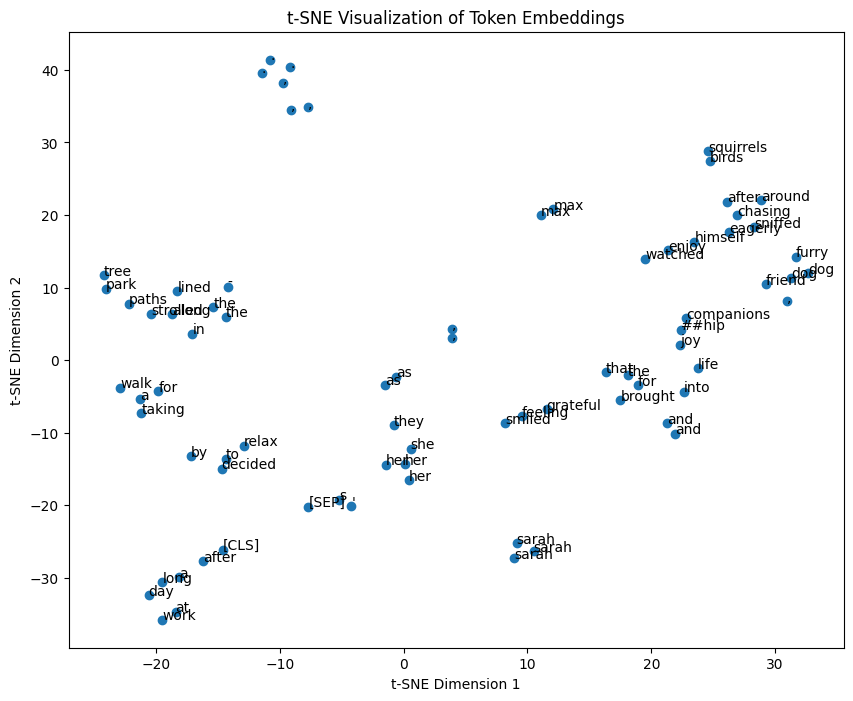

In [22]:
# t-SNE: t-Distributed Stochastic Neighbor Embedding 
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=5, random_state=42) # ???
embeddings_tsne = tsne.fit_transform(last_hidden_states[0])

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_tsne[:, 0],
            embeddings_tsne[:, 1], marker='o')
for i, word in enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])):
  plt.annotate(word,
               xy=(embeddings_tsne[i, 0], embeddings_tsne[i, 1]),
               fontsize=10)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Token Embeddings')
plt.show()

In [7]:
# positional encoding

from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

input_text = '''
After a long day at work, Sarah decided to relax by taking her
dog for a walk in the park. As they strolled along the
tree-lined paths, Sarah's dog, Max, eagerly sniffed around,
chasing after squirrels and birds. Sarah smiled as she watched
Max enjoy himself, feeling grateful for the companionship and
joy that her furry friend brought into her life.'''

tokens = tokenizer(input_text, return_tensors="pt")
embeddings = model.embeddings
positional_embeddings = embeddings.position_embeddings.weight
position_ids = torch.arange(tokens['input_ids'].size(1),
                            dtype=torch.long).unsqueeze(0)
input_positional_encodings = positional_embeddings[position_ids]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


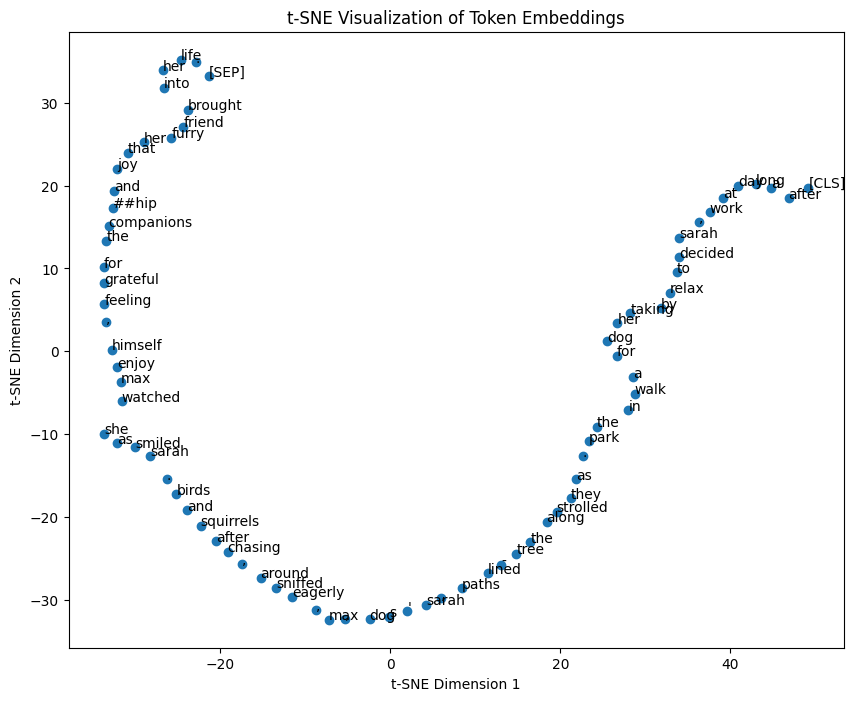

In [11]:
# t-SNE: t-Distributed Stochastic Neighbor Embedding 
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=5, random_state=42) # ???
embeddings_tsne = tsne.fit_transform(input_positional_encodings[0].detach().numpy())

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_tsne[:, 0],
            embeddings_tsne[:, 1], marker='o')
for i, word in enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])):
  plt.annotate(word,
               xy=(embeddings_tsne[i, 0], embeddings_tsne[i, 1]),
               fontsize=10)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization of Token Embeddings')
plt.show()

### Text classification

In [16]:
question_classifier = pipeline("text-classification", model=_model_huaen_question_detection)

inputs = '''Have you ever pondered the mysteries that lie beneath
the surface of everyday life?'''
result = question_classifier(inputs=inputs)
print(result)

inputs = '''"Life is a journey that must be traveled, no matter
how bad the roads and accommodations." - Oliver Goldsmith'''
result = question_classifier(inputs=inputs)
print(result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'question', 'score': 0.9975988268852234}]
[{'label': 'non_question', 'score': 0.9996856451034546}]


### Text generation

In [19]:
generator = pipeline("text-generation", model=_model_openai_gpt2)

generator("The sky is blue")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[{'generated_text': "The sky is blue and the clouds are white. We're both on a flight of time, and you're all in the clouds! The moment we stop and go to sleep, we're all in the same sky. Let's go do something nice for each other!\n\nWe're back on the ground after a long day, so I don't feel like I'm getting too excited about the sun. It's starting to cool down, and I'm feeling better. I'm not happy that I can't be here anymore. The sun's going to come back after a while, and I'm going to have to get back on the ground. You're here for me, and I'm here for you!\n\nI'm about to go into a panic mode when I hear the sound of my friend's voice, and I feel sick. I feel like I'm going to get a little sick. I'm going to go into the deep end of the earth, and I'm going to go into the deep end of the world. Maybe I can just stay here. Maybe I can just go inside the house and do some work. Maybe I can just play video games. Or maybe I can just be myself and go to bed.\n\nI'm not sure if I can do

### Text summarization

### Text translation

### Zero-shot classification

### Question answering

## CV

In [25]:
from PIL import Image, ImageDraw, ImageFont

image = Image.open("data/images/pexels-vitaliy-haiduk-326720599-32995485.jpg")

### Object detection

In [32]:
# Hugging Face in Action - Using the model directly

from transformers import DetrImageProcessor, DetrForObjectDetection

image_processor = DetrImageProcessor.from_pretrained(_model_detr_resnet)
model = DetrForObjectDetection.from_pretrained(_model_detr_resnet)

inputs = image_processor(images=image, return_tensors="pt")
outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])
results = image_processor.post_process_object_detection(
    outputs,
    target_sizes=target_sizes,
    threshold=0.9)[0]

draw = ImageDraw.Draw(image)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
  box = [round(i, 2) for i in box.tolist()]
  print(
      f"Detected {model.config.id2label[label.item()]} with confidence "
      f"{(score.item() * 100):.2f}% at {box}"
  )
  r = random.randint(0, 255)
  g = random.randint(0, 255)
  b = random.randint(0, 255)
  color = (r, g, b)
  draw.rectangle(box,
                 outline=color,
                 width=2)
  draw.text((box[0], box[1]-10),
            model.config.id2label[label.item()],
            fill='white')
image.save("data/images/detected_result_d.jpg")
# image

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Detected car with confidence 99.76% at [512.09, 5354.14, 1345.39, 5988.31]
Detected truck with confidence 98.64% at [1223.58, 2570.15, 1418.14, 2729.99]
Detected car with confidence 99.36% at [1338.4, 3580.19, 1752.94, 3889.86]
Detected car with confidence 99.50% at [2201.4, 4401.52, 2818.7, 4815.8]
Detected car with confidence 98.04% at [1985.74, 3260.18, 2333.19, 3516.22]
Detected truck with confidence 95.28% at [880.16, 2647.72, 1095.99, 2804.35]
Detected truck with confidence 99.25% at [2508.4, 2504.75, 2996.87, 3063.67]
Detected car with confidence 94.58% at [1638.54, 2795.93, 1855.91, 2980.67]
Detected car with confidence 99.74% at [1202.38, 4091.22, 1675.31, 4429.23]
Detected truck with confidence 92.73% at [1243.27, 2806.66, 1491.08, 3010.81]
Detected car with confidence 98.84% at [2348.01, 3005.43, 2595.69, 3215.67]
Detected car with confidence 94.46% at [1239.53, 2807.43, 1486.59, 3003.98]
Detected car with confidence 97.33% at [1489.83, 2997.14, 1779.27, 3224.77]
Detected ca

In [33]:
# Hugging Face in Action - Using the transformers pipeline

detection = pipeline("object-detection", model=_model_detr_resnet)

results = detection(image)

draw = ImageDraw.Draw(image)
try:
    font = ImageFont.truetype("arial.ttf", 20)
except:
    font = None
for res in results:
    box = res["box"]
    label = res["label"]
    score = res["score"]
    
    # 提取坐标 [xmin, ymin, xmax, ymax]
    coords = [box["xmin"], box["ymin"], box["xmax"], box["ymax"]]
    
    # 画矩形框 (outline 是边框颜色，width 是粗细)
    draw.rectangle(coords, outline="red", width=3)
    
    # 画标签和置信度
    text = f"{label}: {round(score, 2)}"
    draw.text((box["xmin"], box["ymin"] - 25), text, fill="red", font=font)

image.save("data/images/detected_result_p.jpg")
# image

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# TODO: webcam with OpenCV

### Image classification

### Image segmentation

### Video classification

### Depth estimation

### Image-to-image

### Unconditional image generation

### Zero-shot image classification

# Datasets

In [34]:
from datasets import load_dataset

ds = load_dataset("stanfordnlp/imdb")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [45]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
# ds['train'][0]

# shuffle
shuffled_dataset = ds.shuffle(seed=42)
# shuffled_dataset['train'][0]

{'text': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier\'s plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it\'s the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...',
 'label': 1}

In [48]:
# tokenizing datasets

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(_model_distilbert)
tokenized_ds = ds.map(lambda examples:
                      tokenizer(examples['text'],
                                truncation=True, padding='max_length'),
                      batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [49]:
tokenized_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [51]:
input_ids_0 = tokenized_ds['train'][0]['input_ids']
tokens_0 = tokenizer.convert_ids_to_tokens(input_ids_0)
# tokens_0

## Visualizing datasets

In [55]:
!hf download --type dataset zeroshot/twitter-financial-news-topic

✓ Downloaded
  path: D:\software\huggingface\hub\datasets--zeroshot--twitter-financial-news-topic\snapshots\acbc8af2a35ccf0916124efcbe9e6cf25f191012



Fetching 5 files: 100%|██████████| 5/5 [00:02<00:00,  1.69it/s]


In [58]:
!hf download --type dataset uoft-cs/cifar10

✓ Downloaded
  path: D:\software\huggingface\hub\datasets--uoft-cs--cifar10\snapshots\0b2714987fa478483af9968de7c934580d0bb9a2
✓ Downloaded
  path: D:\software\huggingface\hub\datasets--uoft-cs--cifar10\snapshots\0b2714987fa478483af9968de7c934580d0bb9a2



Fetching 4 files: 100%|██████████| 4/4 [02:36<00:00, 39.08s/it]

Fetching 4 files: 100%|██████████| 4/4 [00:01<00:00,  2.40it/s]


# Ollama

In [ ]:
from ollama import chat
import pprint

MODEL_gemma4_e4b = 'gemma4:e4b'

def get_temperature(city: str) -> str:
  """Get the current temperature for a city
  
  Args:
    city: The name of the city

  Returns:
    The current temperature for the city
  """
  temperatures = {
    "New York": "22°C",
    "London": "15°C",
    "Tokyo": "18°C",
  }
  return temperatures.get(city, "Unknown")

messages = [{"role": "user", "content": "What is the temperature in New York?"}]

# pass functions directly as tools in the tools list or as a JSON schema
response = chat(model=MODEL_gemma4_e4b, messages=messages, tools=[get_temperature], think=True)
pprint.pprint(response)

messages.append(response.message)
if response.message.tool_calls:
  # only recommended for models which only return a single tool call
  call = response.message.tool_calls[0]
  result = get_temperature(**call.function.arguments)
  # add the tool result to the messages
  messages.append({"role": "tool", "tool_name": call.function.name, "content": str(result)})

  final_response = chat(model=MODEL_gemma4_e4b, messages=messages, tools=[get_temperature], think=True)
  pprint.pprint(final_response)
  print(final_response.message.content)

ChatResponse(model='gemma4:e4b', created_at='2026-05-08T08:59:44.8386606Z', done=True, done_reason='stop', total_duration=33862287200, load_duration=9118461400, prompt_eval_count=77, prompt_eval_duration=2955376500, eval_count=222, eval_duration=21399633400, message=Message(role='assistant', content='', thinking='1. **Analyze the user\'s request:** The user is asking "What is the temperature in New York?".\n\n2. **Examine available tools:** The provided tool is `get_temperature`.\n\n3. **Analyze the `get_temperature` tool:**\n    *   `description`: "Get the current temperature for a city"\n    *   `parameters`:\n        *   `city`: (STRING, required) "The name of the city"\n\n4. **Determine if the tool can fulfill the request:** The request asks for the temperature in "New York". The tool requires a `city` name. "New York" is a valid city name that can be passed to the `city` parameter.\n\n5. **Construct the tool call:**\n    *   Tool name: `get_temperature`\n    *   Arguments: `{"city

: 

# Cleanup

In [57]:
!hf cache ls

ID                                    SIZE LAST_ACCESSED  LAST_MODIFIED  REFS           
----------------------------------- ------ -------------- -------------- ---------------
dataset/stanfordnlp/imdb             83.5M 20 minutes ago 20 minutes ago main           
dataset/uoft-cs/cifar10              23.9M 48 seconds ago 48 seconds ago main           
dataset/zeroshot/twitter-financi...   3.0M 3 minutes ago  3 minutes ago  main           
model/bert-base-uncased             441.1M 3 hours ago    5 hours ago    main           
model/facebook/detr-resnet-50       166.6M 40 minutes ago 3 hours ago    main           
model/huaen/question_detection      867.3M 1 hour ago     7 hours ago    main, refs\pr\2
model/openai-community/gpt2         551.0M 56 minutes ago 56 minutes ago main           

Found 7 repo(s) for a total of 8 revision(s) and 2.1G on disk.


In [44]:
# !hf models info bert-base-uncased
# !hf datasets info stanfordnlp/imdb